##### DAMO630 Advanced Data Analytics 
#### Assignment 1 - Group 2
Bruno de Arantes Leite Sassi (NF1008627)
Sai Bhaskar Chundru (NF1010427)
Tiago Caramello Ceolato (NF1006634)
Yuvraj Singh (NF1016125)

### **Business Challenge 2: Market Basket Analysis for E-Commerce Optimization**

**Introduction**

This notebook performs an end-to-end **affinity / market basket analysis** on the **Online Retail** transaction dataset from the UCI Machine Learning Repository. The goal is to uncover products that are frequently purchased together to support:

- Product recommendations ("customers also bought"),
- Cross-selling / bundling strategies,
- Inventory planning and replenishment,
- Regional assortment and marketing decisions.


---

## Table of Contents
1. **Task I:** Data Exploration & Transaction Preparation  
2. **Task II:** Apriori Algorithm Implementation & Analysis  
3. **Task III:** Association Rule Generation & Evaluation  
4. **Task IV:** Advanced Analysis & Business Applications  

---



# Task I: Data Exploration & Transaction Preparation





### Dataset Overview

The Online Retail dataset contains transactional data from a UK-based online gift store. Each row represents a product purchased within a transaction.

This dataset is used to perform market basket analysis to discover products that are frequently purchased together.


In [0]:
%pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 118.7 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 2.2.0
    Not uninstalling threadpoolctl at /databricks/python3/lib/python3.11/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-61e96dae-f829-4cb7-84ac-cf937f1b3ce1
    Can't uninstall 'threadpoolctl'. No files were found to uninstall.
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Not uninstalling numpy at /databricks/python3/lib/python3.11/site-packages, outside environment /lo

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apriori import
from time import perf_counter
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules


# Load Online Retail dataset (fixed encoding)
df = pd.read_csv("Online Retail.csv", encoding="latin1")

# 1. Basic dataset shape
print("Rows, columns:", df.shape, "\n")

# 2. Data types and null values
print("Dataset Info:")
print(df.info(), "\n")

# 3. Numerical statistics
print("Numerical statistics:")
print(df.describe(), "\n")

# 4. Categorical statistics
print("Categorical columns:")
print(df.select_dtypes(include='object').describe(), "\n")

# 5. Sample data
print("Sample rows:")
print(df.head())


Rows, columns: (541909, 8) 

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None 

Numerical statistics:
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.00000

### Dataset Structure

The dataset contains 541,909 rows and 8 columns, representing individual product transactions. Most columns are categorical, while Quantity and UnitPrice are numerical fields.

The CustomerID column has a significant number of missing values, which will need to be handled during data cleaning to ensure accurate analysis.


## Data Quality Assessment

### Why data quality matters here
Market basket analysis is extremely sensitive to noisy records:
- **Cancelled invoices** can invert real purchasing patterns (items returned/cancelled are not true demand).
- **Negative quantities** often represent returns or corrections.
- **Negative prices** can represent data entry errors or adjustments.
- **Missing customer IDs** reduce customer-level analytics but do not necessarily prevent invoice-level affinity analysis.

Below we quantify these issues before deciding how to treat them.



In [0]:
# Missing values profile
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_df



,missing_count,missing_pct
CustomerID,135080,24.93
Description,1454,0.27
InvoiceNo,0,0.00
StockCode,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


### Missing Values Analysis

The dataset shows missing values mainly in the CustomerID column, with about 24.9% of the records missing this information. A small number of records also have missing product descriptions.

Since CustomerID is important for analyzing purchasing behavior and generating meaningful association rules, rows with missing CustomerID will be removed during preprocessing.


In [0]:
# Cancelled transactions (InvoiceNo begins with 'C')

df['InvoiceNo'] = df['InvoiceNo'].astype(str)
is_cancel = df['InvoiceNo'].str.startswith('C', na=False)
print('Cancelled rows:', is_cancel.sum())
print('Cancelled invoices:', df.loc[is_cancel, 'InvoiceNo'].nunique())

# Revenue column for diagnostics
# Quantity * UnitPrice can be negative if return/adjustment

df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.loc[is_cancel].head()



Cancelled rows: 9288
Cancelled invoices: 3836


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
141,C536379,D,Discount,-1,2010-12-01 9:41,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 9:49,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24,0.29,17548.0,United Kingdom,-6.96


### Cancelled Transactions Analysis

The dataset contains 9,288 cancelled rows across 3,836 invoices. These transactions are identified by invoice numbers starting with the letter “C” and typically include negative quantities or revenues.

Cancelled transactions do not represent actual purchases and can distort association rule results. so , these records will be removed to ensure the analysis reflects real customer buying behavior.


/databricks/python/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/databricks/python/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


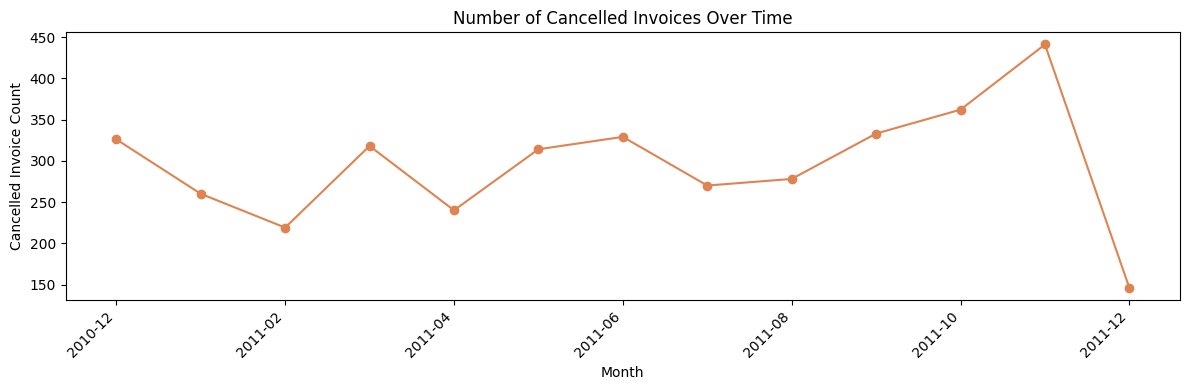

In [0]:
# VIS 2: Cancellations over time (monthly)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)

cancel_month = df.loc[is_cancel].groupby('Month')['InvoiceNo'].nunique()
plt.figure(figsize=(12,4))
cancel_month.plot(marker='o', color='#DD8452')
plt.title('Number of Cancelled Invoices Over Time')
plt.ylabel('Cancelled Invoice Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



### Cancelled Invoices Trend

The chart shows the monthly pattern of cancelled invoices. The number of cancellations fluctuates throughout the year, generally ranging between 200 and 350 invoices per month. However, there is a noticeable spike toward the end of the year, where cancellations rise to around 450 invoices before dropping sharply in the following month.

From a business perspective, the sudden increase in cancellations during certain months may be linked to seasonal sales, returns after peak shopping periods, or promotional campaigns. 


Negative Quantity rows: 10624
Negative UnitPrice rows: 2
Zero UnitPrice rows: 2515


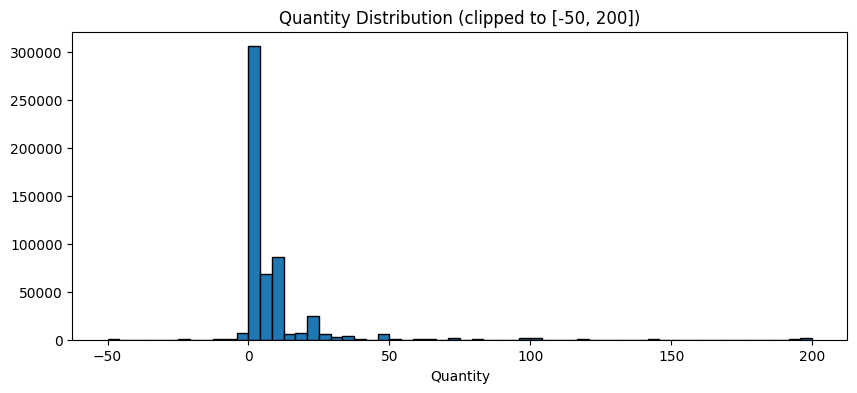

In [0]:
import matplotlib.pyplot as plt

# Negative quantity / price checks
neg_qty = (df['Quantity'] < 0).sum()
neg_price = (df['UnitPrice'] < 0).sum()
zero_price = (df['UnitPrice'] == 0).sum()

print('Negative Quantity rows:', neg_qty)
print('Negative UnitPrice rows:', neg_price)
print('Zero UnitPrice rows:', zero_price)

# VIS 3: Quantity distribution (trimmed)
plt.figure(figsize=(10,4))
q = df['Quantity'].clip(lower=-50, upper=200)
plt.hist(q, bins=60, edgecolor='black')
plt.title('Quantity Distribution (clipped to [-50, 200])')
plt.xlabel('Quantity')
plt.show()


### Negative and Zero Value Analysis

The dataset contains over 10,000 rows with negative quantities, 2 rows with negative unit prices, and 2,515 rows with zero unit prices. These values typically represent product returns, discounts, or data entry issues rather than actual sales.

The quantity distribution shows that most transactions have small positive quantities, while negative values form a separate group of return transactions.

From a business perspective, these records do not reflect real purchase behavior and may distort association rule results. Therefore, transactions with negative or zero quantities and prices will be removed to ensure the analysis focuses only on valid sales.


## Cleaning Strategy (with business justification)

**Decision 1 — Remove cancellations (`InvoiceNo` starts with `C`)**  
Cancelled invoices represent orders that did not complete. Including them would distort co-purchase patterns and make the model recommend combinations associated with returns.

**Decision 2 — Remove negative quantities / negative prices**  
Negative values are typically returns or corrections. Basket analysis aims to capture *positive demand* (what was bought), not reverse logistics.

**Decision 3 — Drop records with missing `Description`**  
Without a product label, the item can’t be used in association mining.

**Decision 4 — Handle missing `CustomerID`**  
CustomerID is not required for invoice-level baskets. We keep those rows unless other critical fields are missing.

**Decision 5 — Remove exact duplicates**  
Duplicates can inflate support for itemsets (false popularity).



In [0]:
# Apply cleaning

df_clean = df.copy()

# 1) Remove cancellations
mask_cancel = df_clean['InvoiceNo'].str.startswith('C', na=False)
df_clean = df_clean.loc[~mask_cancel].copy()

# 2) Remove non-positive quantity and price
# (Zero price may be promotions/samples; for basket patterns it can add noise)
df_clean = df_clean.loc[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)].copy()

# 3) Drop missing descriptions

df_clean = df_clean.dropna(subset=['Description']).copy()

# 4) Drop duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print('Rows after cleaning:', df_clean.shape)
print('Duplicates removed:', before - len(df_clean))

df_clean.head()



Rows after cleaning: (524878, 10)
Duplicates removed: 5226


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


### Cleaned Dataset Summary

After removing missing customer records, cancelled transactions, negative or zero values, and duplicate rows, the dataset was reduced to 524,878 valid transaction records. A total of 5226 duplicate rows were removed during the cleaning process.

The cleaned dataset now represents only genuine customer purchases, making it suitable for accurate market basket analysis and association rule mining.


## 3) Descriptive Statistics
We compute:
- Number of unique transactions (InvoiceNo)
- Number of unique products (StockCode)
- Number of unique customers
- Distribution of basket sizes (items per invoice)
- Revenue distribution by country



In [0]:
# Unique counts
n_invoices = df_clean['InvoiceNo'].nunique()
n_products = df_clean['StockCode'].nunique()
n_customers = df_clean['CustomerID'].nunique()  # missing IDs excluded

print('Unique invoices:', n_invoices)
print('Unique products:', n_products)
print('Unique customers (non-missing):', n_customers)

# Basket size (unique SKUs per invoice)
basket_sizes = df_clean.groupby('InvoiceNo')['StockCode'].nunique()

# Country revenue
country_rev = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

basket_sizes.describe()



Unique invoices: 19960
Unique products: 3922
Unique customers (non-missing): 4338


count    19960.000000
mean        26.032164
std         46.982195
min          1.000000
25%          6.000000
50%         15.000000
75%         29.000000
max       1110.000000
Name: StockCode, dtype: float64

### Transaction and Customer Overview

After cleaning, the dataset contains:
- 19,960 unique transactions
- 3,922 unique products
- 4,338 unique customers

The average basket size is about 26 items per transaction, with most baskets containing between 6 and 29 items. However, some transactions contain very large quantities, indicating bulk purchases or wholesale orders.


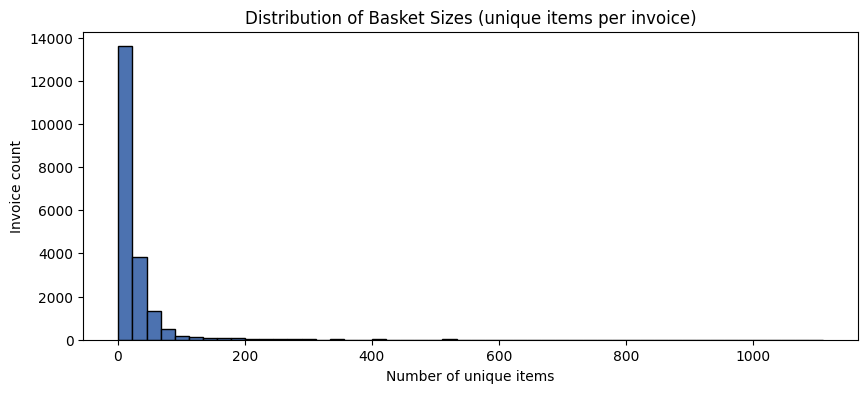

In [0]:
# VIS 5: Basket size distribution
plt.figure(figsize=(10,4))
plt.hist(basket_sizes, bins=50, color='#4C72B0', edgecolor='black')
plt.title('Distribution of Basket Sizes (unique items per invoice)')
plt.xlabel('Number of unique items')
plt.ylabel('Invoice count')
plt.show()



### Basket Size Distribution

The basket size distribution shows that most transactions contain a small number of unique items, while a few transactions have very large basket sizes.

This indicates that the majority of customers make small or medium-sized purchases, while a smaller segment of customers places bulk orders. These patterns are important for understanding typical buying behavior and designing product bundles.


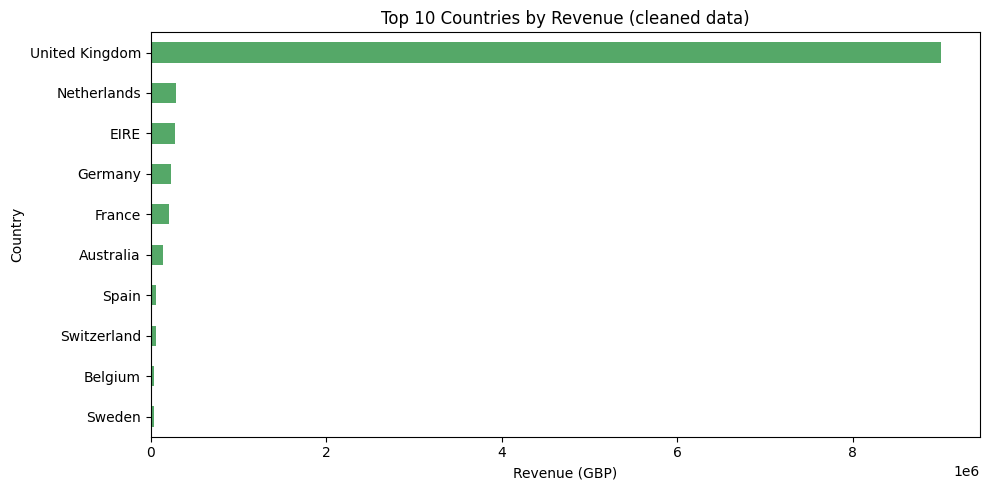

In [0]:
# VIS 6: Revenue by top 10 countries
plt.figure(figsize=(10,5))
country_rev.head(10).sort_values().plot(kind='barh', color='#55A868')
plt.title('Top 10 Countries by Revenue (cleaned data)')
plt.xlabel('Revenue (GBP)')
plt.tight_layout()
plt.show()



### Revenue by Country

The revenue distribution shows that the United Kingdom contributes the majority of total sales, far exceeding other countries. The Netherlands, Ireland, Germany, and France follow as secondary markets with significantly lower revenue.

This indicates that the business is heavily concentrated in the UK market, with international sales forming a smaller portion of total revenue.


## Transaction format (InvoiceNo as basket)

Association rule mining needs:
- one row per invoice
- one column per item
- binary presence/absence (1 if item appears in the invoice)

### Transaction Preparation

To apply the Apriori algorithm, the dataset is converted into a basket format where each row represents a transaction and each column represents a product. Only products that appear in at least 50 invoices are retained to reduce noise and improve rule quality.




In [0]:

MIN_ITEM_INVOICES = 50

# Standardize product names

df_clean['Description'] = df_clean['Description'].astype(str).str.strip().str.upper()

# Frequency: in how many invoices each item appears
item_invoice_counts = df_clean.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending=False)
keep_items = item_invoice_counts[item_invoice_counts >= MIN_ITEM_INVOICES].index

print('Items before filter:', df_clean['Description'].nunique())
print('Items after  filter:', len(keep_items))

# Build invoice x item matrix
basket_df = (df_clean[df_clean['Description'].isin(keep_items)]
             .groupby(['InvoiceNo','Description'])['Quantity']
             .sum()
             .unstack(fill_value=0))

basket_binary = (basket_df > 0).astype(int)
print('Basket matrix shape (invoices x items):', basket_binary.shape)

basket_binary.head()



Items before filter: 4015
Items after  filter: 2185
Basket matrix shape (invoices x items): (19748, 2185)


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE SKULLS,12 PENCILS TALL TUBE WOODLAND,12 RED ROSE PEG PLACE SETTINGS,15CM CHRISTMAS GLASS BALL 20 LIGHTS,16 PIECE CUTLERY SET PANTRY DESIGN,20 DOLLY PEGS RETROSPOT,200 BENDY SKULL STRAWS,200 RED + WHITE BENDY STRAWS,3 DRAWER ANTIQUE WHITE WOOD CABINET,3 GARDENIA MORRIS BOXED CANDLES,3 HEARTS HANGING DECORATION RUSTIC,3 HOOK HANGER MAGIC GARDEN,3 HOOK PHOTO SHELF ANTIQUE WHITE,3 PIECE SPACEBOY COOKIE CUTTER SET,3 RAFFIA RIBBONS 50'S CHRISTMAS,3 RAFFIA RIBBONS VINTAGE CHRISTMAS,3 ROSE MORRIS BOXED CANDLES,3 STRIPEY MICE FELTCRAFT,3 TIER CAKE TIN GREEN AND CREAM,3 TIER CAKE TIN RED AND CREAM,3 TRADITIONAL BISCUIT CUTTERS SET,3 WHITE CHOC MORRIS BOXED CANDLES,36 DOILIES DOLLY GIRL,36 DOILIES VINTAGE CHRISTMAS,36 FOIL HEART CAKE CASES,36 FOIL STAR CAKE CASES,36 PENCILS TUBE RED RETROSPOT,36 PENCILS TUBE SKULLS,36 PENCILS TUBE WOODLAND,...,WRAP ALPHABET POSTER,WRAP BILLBOARD FONTS DESIGN,WRAP BIRD GARDEN,WRAP CHRISTMAS VILLAGE,WRAP CIRCUS PARADE,WRAP COWBOYS,WRAP DOILEY DESIGN,WRAP DOLLY GIRL,WRAP ENGLISH ROSE,WRAP FLOWER SHOP,WRAP GINGHAM ROSE,WRAP GREEN PEARS,WRAP I LOVE LONDON,WRAP PAISLEY PARK,WRAP PINK FAIRY CAKES,WRAP POPPIES DESIGN,WRAP RED APPLES,WRAP RED VINTAGE DOILY,WRAP SUKI AND FRIENDS,WRAP VINTAGE LEAF DESIGN,WRAP VINTAGE PETALS DESIGN,YELLOW COAT RACK PARIS FASHION,YELLOW GIANT GARDEN THERMOMETER,YELLOW METAL CHICKEN HEART,YELLOW SHARK HELICOPTER,YOU'RE CONFUSING ME METAL SIGN,YULETIDE IMAGES GIFT WRAP SET,ZINC HEART T-LIGHT HOLDER,ZINC BOX SIGN HOME,ZINC FINISH 15CM PLANTER POTS,ZINC FOLKART SLEIGH BELLS,ZINC HEART FLOWER T-LIGHT HOLDER,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC HEARTS PLANT POT HOLDER,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC WILLIE WINKIE CANDLE STICK
InvoiceNo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


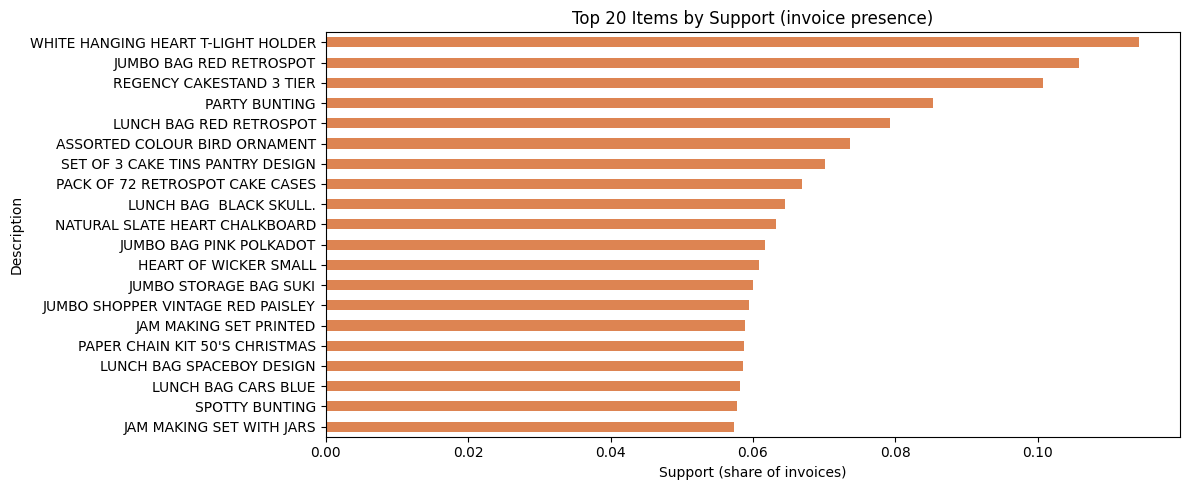

In [0]:
# VIS 8: Top 20 frequent individual items (support)
item_support = basket_binary.mean().sort_values(ascending=False)

top20 = item_support.head(20)
plt.figure(figsize=(12,5))
top20.sort_values().plot(kind='barh', color='#DD8452')
plt.title('Top 20 Items by Support (invoice presence)')
plt.xlabel('Support (share of invoices)')
plt.tight_layout()
plt.show()



### Frequent Itemsets Overview

The chart shows the top products ranked by support, which represents the proportion of transactions containing each item. 

Items such as "WHITE HANGING HEART T-LIGHT HOLDER", "JUMBO BAG RED RETROSPOT", and "REGENCY CAKESTAND 3 TIER" have the highest support, appearing in a significant share of invoices. This indicates that these are among the store’s most popular products.

From a business perspective, these high-support items act as core products that attract customers. They can be used for cross-selling, bundle promotions, and homepage recommendations to increase overall basket value.


# Task II: Apriori Algorithm Implementation & Analysis

## 1) Simplified Apriori (from scratch)

### Apriori explanation (human, clear)
- We start with **1-itemsets**, count how often each item appears, and keep those above `min_support`.
- Then we generate **candidate 2-itemsets** by joining frequent 1-itemsets.
- We apply the **Apriori principle**: if any (k−1)-subset of a k-item candidate is infrequent, we drop that candidate.
- We continue level-by-level until no new frequent itemsets are found.

The simplified implementation runs on a sample of invoices so it finishes quickly, while still proving understanding.



In [0]:
# Prepare sampled transactions list for simplified Apriori
SAMPLE_INVOICES = 5000

invoice_list = basket_binary.index.to_series().sample(min(SAMPLE_INVOICES, len(basket_binary)), random_state=42)

sample_tx = []
for inv in invoice_list:
    items = basket_binary.columns[basket_binary.loc[inv] == 1]
    sample_tx.append(set(items))

len(sample_tx), list(sample_tx[0])[:10]



(5000,
 ['RED DRAWER KNOB ACRYLIC EDWARDIAN',
  'BLUE DRAWER KNOB ACRYLIC EDWARDIAN',
  'SWEETHEART CAKESTAND 3 TIER',
  'GREEN DRAWER KNOB ACRYLIC EDWARDIAN',
  'CLEAR DRAWER KNOB ACRYLIC EDWARDIAN',
  'RED STRIPE CERAMIC DRAWER KNOB',
  'WHITE SPOT BLUE CERAMIC DRAWER KNOB',
  'PURPLE DRAWERKNOB ACRYLIC EDWARDIAN',
  'PINK DRAWER KNOB ACRYLIC EDWARDIAN',
  'BLUE SPOT CERAMIC DRAWER KNOB'])

### Transaction Sampling for Apriori

To simplify the Apriori implementation, a sample of 5,000 invoices was selected from the transaction dataset. Each invoice was converted into a set of purchased items, creating a list of transactions suitable for frequent itemset mining.

This step reduces computational complexity while still preserving the overall purchasing patterns in the dataset, allowing the Apriori algorithm to run efficiently.


### Apriori Algorithm

**Apriori Principle:**
The core idea of the Apriori algorithm is that if an itemset is frequent, all of its subsets must also be frequent. Conversely, if a subset is not frequent, any larger itemset containing it cannot be frequent. This principle helps reduce the number of candidate itemsets and improves computational efficiency.

**Candidate Itemset Generation:**
The algorithm begins by identifying frequent single items (L1) that meet the minimum support threshold. These items are then combined to form candidate pairs (C2). After calculating their support, only the frequent pairs (L2) are retained. This process continues for larger itemsets until no more frequent combinations are found.

**Level-wise Search Approach:**
Apriori works in multiple levels:
- L1: Frequent single items
- L2: Frequent pairs
- L3: Frequent triplets,    And so on

At each level, the algorithm:
1. Generates candidate itemsets from the previous level.
2. Calculates their support.
3. Prunes itemsets that do not meet the minimum support threshold.

This iterative approach ensures that only meaningful and frequent product combinations are retained for association rule generation.


In [0]:
from itertools import combinations
import numpy as np

def apriori_simple(transactions, min_support=0.02, max_len=3):
    n = len(transactions)
    min_count = int(np.ceil(min_support * n))

    # L1: count single items
    item_counts = {}
    for t in transactions:
        for i in t:
            item_counts[i] = item_counts.get(i, 0) + 1

    Lk = {frozenset([i]) for i, c in item_counts.items() if c >= min_count}
    freq = {fs: item_counts[list(fs)[0]] / n for fs in Lk}

    k = 2
    while Lk and k <= max_len:
        # Generate candidates
        candidates = {a | b for a in Lk for b in Lk if len(a | b) == k}

        # Prune
        candidates = {
            c for c in candidates
            if all(frozenset(s) in Lk for s in combinations(c, k - 1))
        }

        # Count support
        Lk_new = set()
        for c in candidates:
            count = sum(1 for t in transactions if c.issubset(t))
            if count >= min_count:
                freq[c] = count / n
                Lk_new.add(c)

        Lk = Lk_new
        k += 1

    return freq

min_sup_demo = 0.02
start = perf_counter()

freq_demo = apriori_simple(sample_tx, min_support=min_sup_demo, max_len=3)

elapsed = perf_counter() - start

print(f"Simplified Apriori: support={min_sup_demo}, itemsets={len(freq_demo)}, time={elapsed:.2f}s")

# Top 10 itemsets
sorted(freq_demo.items(), key=lambda x: (-x[1], len(x[0])))[:10]



Simplified Apriori: support=0.02, itemsets=435, time=17.10s


[(frozenset({'WHITE HANGING HEART T-LIGHT HOLDER'}), 0.1158),
 (frozenset({'JUMBO BAG RED RETROSPOT'}), 0.1152),
 (frozenset({'REGENCY CAKESTAND 3 TIER'}), 0.1032),
 (frozenset({'PARTY BUNTING'}), 0.0888),
 (frozenset({'ASSORTED COLOUR BIRD ORNAMENT'}), 0.0828),
 (frozenset({'LUNCH BAG RED RETROSPOT'}), 0.0814),
 (frozenset({'SET OF 3 CAKE TINS PANTRY DESIGN'}), 0.0728),
 (frozenset({'PACK OF 72 RETROSPOT CAKE CASES'}), 0.0708),
 (frozenset({'JUMBO SHOPPER VINTAGE RED PAISLEY'}), 0.0668),
 (frozenset({'JUMBO BAG PINK POLKADOT'}), 0.0662)]

### L1 Frequent Itemsets (Single Items)

The simplified Apriori implementation identified frequent single items using a minimum support threshold of 0.02. A total of 435 frequent itemsets were discovered from the sampled transactions.

Items such as “WHITE HANGING HEART T-LIGHT HOLDER,” “JUMBO BAG RED RETROSPOT,” and “REGENCY CAKESTAND 3 TIER” have the highest support values, meaning they appear in a large proportion of transactions.

These products represent the store’s most popular items and can be used as core products for promotions, recommendations, and cross-selling strategies.


## 3) Apriori on full (filtered) data with multiple support thresholds
We run Apriori with three minimum support thresholds and compare:
- number of frequent itemsets
- execution time
- how itemset discovery changes



In [0]:
support_thresholds = [0.01, 0.02, 0.05]

# Convert to boolean DataFrame for better memory efficiency
basket_bool = basket_binary.astype(bool)

freq_itemsets_by_sup = {}
times_by_sup = {}

for sup in support_thresholds:
    start = perf_counter()
    # Use low_memory mode and boolean input to reduce memory footprint
    fi_tmp = apriori(basket_bool, min_support=sup, use_colnames=True, low_memory=True)
    fi_tmp['length'] = fi_tmp['itemsets'].apply(len)
    times_by_sup[sup] = perf_counter() - start
    freq_itemsets_by_sup[sup] = fi_tmp
    print(f'Support={sup:0.02f} -> itemsets={len(fi_tmp):,}, time={times_by_sup[sup]:.2f}s')

times_by_sup


Support=0.01 -> itemsets=1,960, time=0.89s
Support=0.02 -> itemsets=389, time=0.21s
Support=0.05 -> itemsets=34, time=0.05s


{0.01: 0.8909282179999991,
 0.02: 0.20820371899998236,
 0.05: 0.046205788999998276}

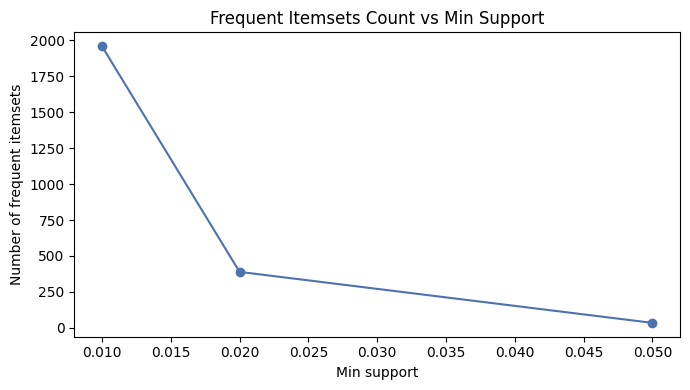

In [0]:
# VIS 9: Frequent itemsets count vs support
counts = pd.Series({sup: len(freq_itemsets_by_sup[sup]) for sup in support_thresholds}).sort_index()
plt.figure(figsize=(7,4))
counts.plot(marker='o', color='#4C72B0')
plt.title('Frequent Itemsets Count vs Min Support')
plt.xlabel('Min support')
plt.ylabel('Number of frequent itemsets')
plt.tight_layout()
plt.show()



### Effect of Minimum Support on Frequent Itemsets

The chart shows how the number of frequent itemsets changes as the minimum support threshold increases. At a lower support of 0.01, nearly 2,000 itemsets are discovered. However, as the support increases to 0.02 and 0.05, the number of frequent itemsets drops significantly.

This indicates that lower support thresholds capture more product combinations, including less common ones, while higher thresholds focus only on the most frequently purchased items.


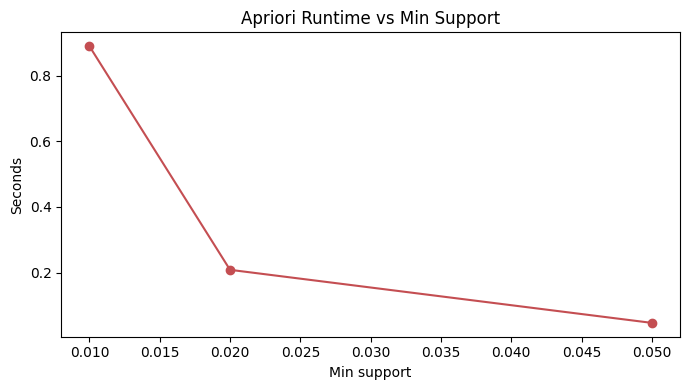

In [0]:
# VIS 10: Runtime vs support
plt.figure(figsize=(7,4))
pd.Series(times_by_sup).sort_index().plot(marker='o', color='#C44E52')
plt.title('Apriori Runtime vs Min Support')
plt.xlabel('Min support')
plt.ylabel('Seconds')
plt.tight_layout()
plt.show()



### Threshold Trade-off Discussion

The analysis demonstrates a clear trade-off between the number of frequent itemsets and computational efficiency. Lower support thresholds produce more itemsets and deeper insights into customer behavior, but they also increase processing time. Higher thresholds reduce runtime but may miss less frequent yet meaningful product combinations.

Therefore, selecting an appropriate support threshold is essential to balance rule quality, interpretability, and computational performance.


In [0]:
# Choose a threshold for deeper analysis
CHOSEN_SUPPORT = 0.02
fi = freq_itemsets_by_sup[CHOSEN_SUPPORT].copy()

# FIX: convert frozensets to readable strings
fi['itemsets'] = fi['itemsets'].apply(lambda x: ', '.join(list(x)))

freq_1 = fi[fi['length'] == 1].sort_values('support', ascending=False)
freq_2 = fi[fi['length'] == 2].sort_values('support', ascending=False)
freq_3 = fi[fi['length'] == 3].sort_values('support', ascending=False)

print('Frequent 1-itemsets:', len(freq_1))
print('Frequent 2-itemsets:', len(freq_2))
print('Frequent 3-itemsets:', len(freq_3))

print('Top 20 items:')
display(freq_1.head(20))

print('Top 15 2-itemsets:')
display(freq_2.head(15))

print('Top 10 3-itemsets (if any):')
display(freq_3.head(10))


Frequent 1-itemsets: 303
Frequent 2-itemsets: 83
Frequent 3-itemsets: 3
Top 20 items:


support,itemsets,length
0.11423941664978732,WHITE HANGING HEART T-LIGHT HOLDER,1
0.10578286408750254,JUMBO BAG RED RETROSPOT,1
0.10066842211869556,REGENCY CAKESTAND 3 TIER,1
0.08532509621227466,PARTY BUNTING,1
0.07919789345756532,LUNCH BAG RED RETROSPOT,1
0.0736783471743974,ASSORTED COLOUR BIRD ORNAMENT,1
0.07013368442373911,SET OF 3 CAKE TINS PANTRY DESIGN,1
0.06684221186955641,PACK OF 72 RETROSPOT CAKE CASES,1
0.06446222402268584,LUNCH BAG BLACK SKULL.,1
0.063246911079603,NATURAL SLATE HEART CHALKBOARD,1


Top 15 2-itemsets:


support,itemsets,length
0.04177638241847276,"JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROSPOT",2
0.03883937613935588,"ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER",2
0.03666194044966579,"JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI",2
0.03443386672068058,"JUMBO SHOPPER VINTAGE RED PAISLEY, JUMBO BAG RED RETROSPOT",2
0.032458983188170955,"LUNCH BAG RED RETROSPOT, LUNCH BAG BLACK SKULL.",2
0.03240834514887583,"ALARM CLOCK BAKELIKE RED, ALARM CLOCK BAKELIKE GREEN",2
0.03200324083451489,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",2
0.030686651812841807,"LUNCH BAG PINK POLKADOT, LUNCH BAG RED RETROSPOT",2
0.03028154749848086,"ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",2
0.02962325298764432,"JUMBO BAG RED RETROSPOT, JUMBO BAG BAROQUE BLACK WHITE",2


Top 10 3-itemsets (if any):


support,itemsets,length
0.027395179258659103,"ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",3
0.02091351022888394,"JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI",3
0.020660320032408346,"REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER",3


### Itemset Analysis at Support = 0.02

Using a minimum support threshold of 0.02, the Apriori algorithm identified 303 frequent single items, 83 frequent item pairs, and 3 frequent three-item combinations.

The large number of single and paired itemsets indicates strong product relationships in customer transactions, while the smaller number of three-item combinations suggests that fewer products are consistently purchased together in larger groups.


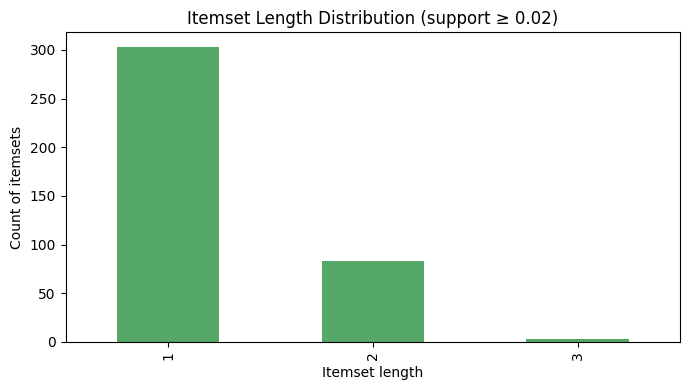

In [0]:
# VIS 11: Itemset length distribution
plt.figure(figsize=(7,4))
fi['length'].value_counts().sort_index().plot(kind='bar', color='#55A868')
plt.title(f'Itemset Length Distribution (support ≥ {CHOSEN_SUPPORT})')
plt.xlabel('Itemset length')
plt.ylabel('Count of itemsets')
plt.tight_layout()
plt.show()



### Itemset Length Distribution

The chart shows the number of frequent itemsets by their size at a support threshold of 0.02. Most of the frequent itemsets are single items, followed by a smaller number of item pairs, and only a few three-item combinations.

This indicates that customers typically purchase one or two strongly related products together, while larger combinations are less common.


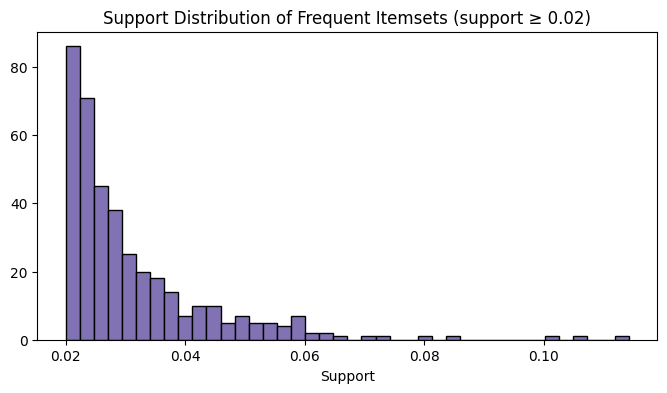

In [0]:
# VIS 12: Support distribution
plt.figure(figsize=(8,4))
plt.hist(fi['support'], bins=40, color='#8172B3', edgecolor='black')
plt.title(f'Support Distribution of Frequent Itemsets (support ≥ {CHOSEN_SUPPORT})')
plt.xlabel('Support')
plt.show()



### Support Distribution of Frequent Itemsets

Most frequent itemsets have support values close to the minimum threshold of 0.02, while only a few itemsets show high support. This indicates that a small number of core products are very popular, whereas most combinations occur less frequently.

### Threshold Impact on Frequent Itemsets

As the minimum support increases, the number of frequent itemsets decreases sharply. Lower thresholds discover more product combinations, while higher thresholds focus only on the most common items.

### Trade-off: Computational Efficiency vs Pattern Discovery

- Lower support → more itemsets and deeper insights, but longer runtime.
- Higher support → fewer itemsets and faster computation, but some useful patterns may be missed.


# Task III: Association Rule Generation & Evaluation

We generate association rules from frequent itemsets using multiple confidence thresholds.

## Metric meanings
- **Support**: how common the combined itemset is
- **Confidence**: how reliable the rule is (P(consequent | antecedent))
- **Lift**: how much more likely the consequent is given antecedent vs random chance



In [0]:
CHOSEN_SUPPORT = 0.02
fi = freq_itemsets_by_sup[CHOSEN_SUPPORT].copy()

# Make sure itemsets are frozensets
print(type(fi['itemsets'].iloc[0]))
fi.head()


<class 'frozenset'>


,support,itemsets,length
0,0.023699,(3 STRIPEY MICE FELTCRAFT),1
1,0.024458,(4 TRADITIONAL SPINNING TOPS),1
2,0.048359,(6 RIBBONS RUSTIC CHARM),1
3,0.022129,(60 CAKE CASES DOLLY GIRL DESIGN),1
4,0.031294,(60 CAKE CASES VINTAGE CHRISTMAS),1


### Frequent Itemsets for Rule Generation

A support threshold of 0.02 was selected to generate frequent itemsets for association rule mining. Each itemset is stored as a frozenset, which allows efficient processing and combination of items during rule generation.

These frequent itemsets form the basis for generating association rules, where relationships between products will be evaluated using support, confidence, and lift metrics.


In [0]:
conf_thresholds = [0.3, 0.5, 0.7]

rules_by_conf = {}
for conf in conf_thresholds:
    r = association_rules(fi, metric='confidence', min_threshold=conf)
    r['antecedent_len'] = r['antecedents'].apply(len)
    r['consequent_len'] = r['consequents'].apply(len)
    rules_by_conf[conf] = r
    print(f'confidence ≥ {conf}: rules={len(r):,}')

# Rules at confidence 0.5
r50 = rules_by_conf[0.5].copy()

# Create a display-safe version of rules
r50_display = r50.copy()
r50_display['antecedents'] = r50_display['antecedents'].apply(lambda x: ', '.join(list(x)))
r50_display['consequents'] = r50_display['consequents'].apply(lambda x: ', '.join(list(x)))


confidence ≥ 0.3: rules=157
confidence ≥ 0.5: rules=63
confidence ≥ 0.7: rules=13


### Rule Counts at Different Confidence Thresholds

Association rules were generated using multiple confidence thresholds. At a confidence level of 0.3, a total of 157 rules were produced. When the confidence threshold increased to 0.5, the number of rules dropped to 63. At a higher threshold of 0.7, only 13 rules remained.

This shows that as the confidence threshold increases, the number of rules decreases. Lower thresholds generate more rules, including weaker associations, while higher thresholds produce fewer but more reliable and stronger rules.


In [0]:
def show_top_rules(rules_df, metric, n=20):
    cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    return rules_df.sort_values(metric, ascending=False)[cols].head(n)

print('Top 20 rules by lift')
display(show_top_rules(r50_display, 'lift', 20))

print('Top 20 rules by confidence')
display(show_top_rules(r50_display, 'confidence', 20))

print('Top 20 rules by support')
display(show_top_rules(r50_display, 'support', 20))


Top 20 rules by lift


antecedents,consequents,support,confidence,lift
"ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER",PINK REGENCY TEACUP AND SAUCER,0.027395179258659103,0.7053455019556715,18.208056173360262
PINK REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER",0.027395179258659103,0.7071895424836601,18.20805617336026
"ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",GREEN REGENCY TEACUP AND SAUCER,0.027395179258659103,0.9046822742474916,17.6363924499896
GREEN REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",0.027395179258659103,0.5340572556762093,17.6363924499896
PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.03200324083451489,0.8261437908496733,16.105318441953948
GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.03200324083451489,0.6238894373149063,16.105318441953948
"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",ROSES REGENCY TEACUP AND SAUCER,0.027395179258659103,0.856012658227848,15.872805610031493
ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",0.027395179258659103,0.5079812206572769,15.872805610031493
GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.027648369455134696,0.5980284775465499,15.580298647215391
GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.027648369455134696,0.7203166226912928,15.58029864721539


Top 20 rules by confidence


antecedents,consequents,support,confidence,lift
"ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",GREEN REGENCY TEACUP AND SAUCER,0.027395179258659103,0.9046822742474916,17.6363924499896
"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",ROSES REGENCY TEACUP AND SAUCER,0.027395179258659103,0.856012658227848,15.872805610031493
PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.03200324083451489,0.8261437908496733,16.105318441953948
"JUMBO BAG PINK POLKADOT, JUMBO STORAGE BAG SUKI",JUMBO BAG RED RETROSPOT,0.02091351022888394,0.8019417475728157,7.581017535216833
"REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACUP AND SAUCER",ROSES REGENCY TEACUP AND SAUCER,0.020660320032408346,0.8015717092337918,14.863322172721992
PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.03028154749848086,0.7816993464052288,14.494834453343152
"REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP AND SAUCER",GREEN REGENCY TEACUP AND SAUCER,0.020660320032408346,0.7771428571428571,15.150066281201523
GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.03883937613935588,0.7571569595261599,14.039751771570522
GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.027648369455134696,0.7203166226912928,15.58029864721539
ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.03883937613935588,0.7201877934272299,14.03975177157052


Top 20 rules by support


antecedents,consequents,support,confidence,lift
JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,0.04177638241847276,0.6773399014778325,6.403115545420889
GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.03883937613935588,0.7571569595261599,14.039751771570522
ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.03883937613935588,0.7201877934272299,14.03975177157052
JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,0.03666194044966579,0.6114864864864864,5.780581682687952
JUMBO SHOPPER VINTAGE RED PAISLEY,JUMBO BAG RED RETROSPOT,0.03443386672068058,0.5787234042553192,5.4708615544442525
LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,0.032458983188170955,0.5035349567949725,6.357933712779486
ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.03240834514887583,0.6089438629876308,12.270840210489524
ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.03240834514887583,0.6530612244897959,12.270840210489524
PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.03200324083451489,0.8261437908496733,16.105318441953948
GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.03200324083451489,0.6238894373149063,16.105318441953948


### Top Association Rules by Different Metrics

- **Top rules by lift** represent the strongest product associations.  
  - These rules show item pairs that occur together much more frequently than expected by chance.
  - For example, different Regency teacup variants appear together with very high lift values, indicating strong complementary relationships.

- **Top rules by confidence** represent the most reliable associations.  
  - A high confidence value means that when the antecedent product is purchased, the consequent product is very likely to be purchased as well.

- **Top rules by support** represent the most common product combinations.  
  - These rules occur frequently across many transactions and indicate popular product pairings.

- **Overall insight:**  
  - Products with high lift, confidence, and support indicate strong and reliable associations.
  - These rules can be used for cross-selling, product bundling, and recommendation systems.


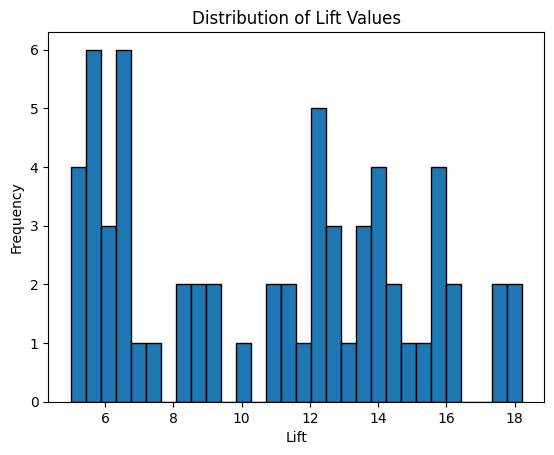

In [0]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(r50['lift'], bins=30, edgecolor='black')
plt.title('Distribution of Lift Values')
plt.xlabel('Lift')
plt.ylabel('Frequency')
plt.show()


### Distribution of Lift Values

The histogram shows that most association rules have lift values between approximately 5 and 16. Since all lift values are well above 1, this indicates strong positive relationships between product pairs. The presence of several high-lift rules suggests that certain products are frequently purchased together far more often than expected by chance.

**Business Insight:**
- Product pairs with high lift represent strong complementary relationships.
- These combinations are ideal for bundle offers, cross-selling, and recommendation systems.


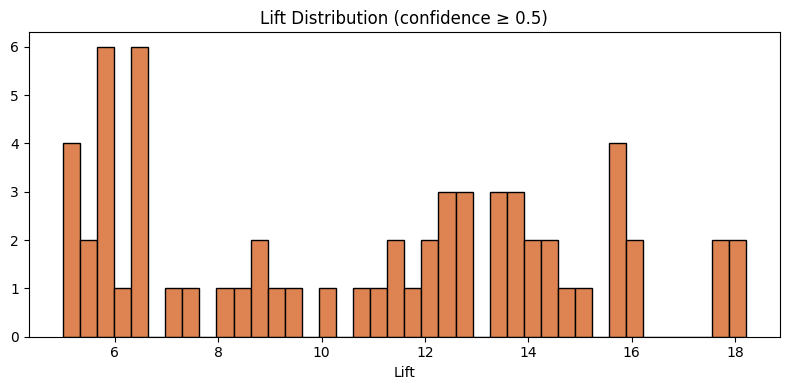

In [0]:
# VIS 13: Lift distribution
plt.figure(figsize=(8,4))
plt.hist(r50['lift'], bins=40, color='#DD8452', edgecolor='black')
plt.title('Lift Distribution (confidence ≥ 0.5)')
plt.xlabel('Lift')
plt.tight_layout()
plt.show()



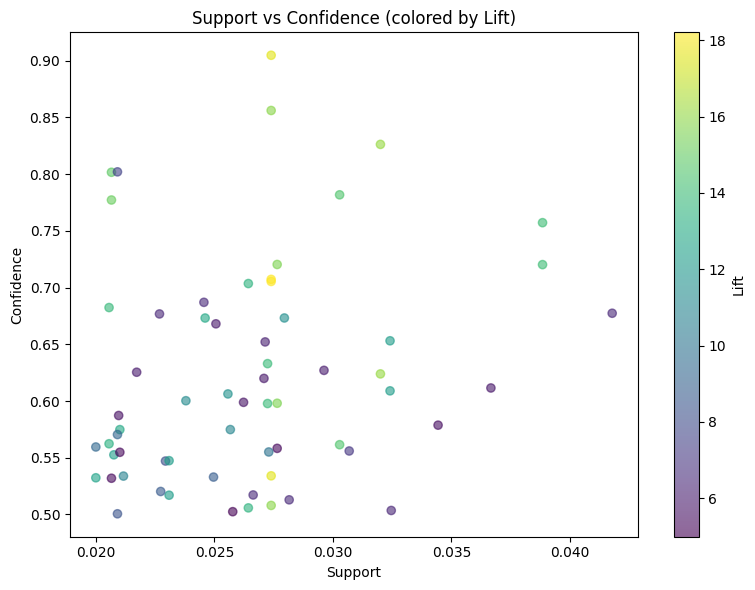

In [0]:
# VIS 14: Support vs Confidence (colored by lift)
plt.figure(figsize=(8,6))
plt.scatter(r50['support'], r50['confidence'], c=r50['lift'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Lift')
plt.title('Support vs Confidence (colored by Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.tight_layout()
plt.show()



### Support vs Confidence Analysis

The scatter plot shows the relationship between support and confidence for the generated association rules, with lift represented by color intensity.

Most rules have support values between 0.02 and 0.03 and confidence values between 0.50 and 0.75, indicating moderately common and reliable product associations. A few rules show higher confidence above 0.80, representing very strong and reliable relationships.

Rules with darker colors indicate higher lift values, meaning those product pairs have stronger associations. Several rules with moderate support and high lift suggest meaningful but not overly common product combinations.

**Business Insight:**
- Rules with high confidence and high lift represent the most valuable cross-selling opportunities.
- These product pairs can be prioritized for bundle offers and recommendation systems.


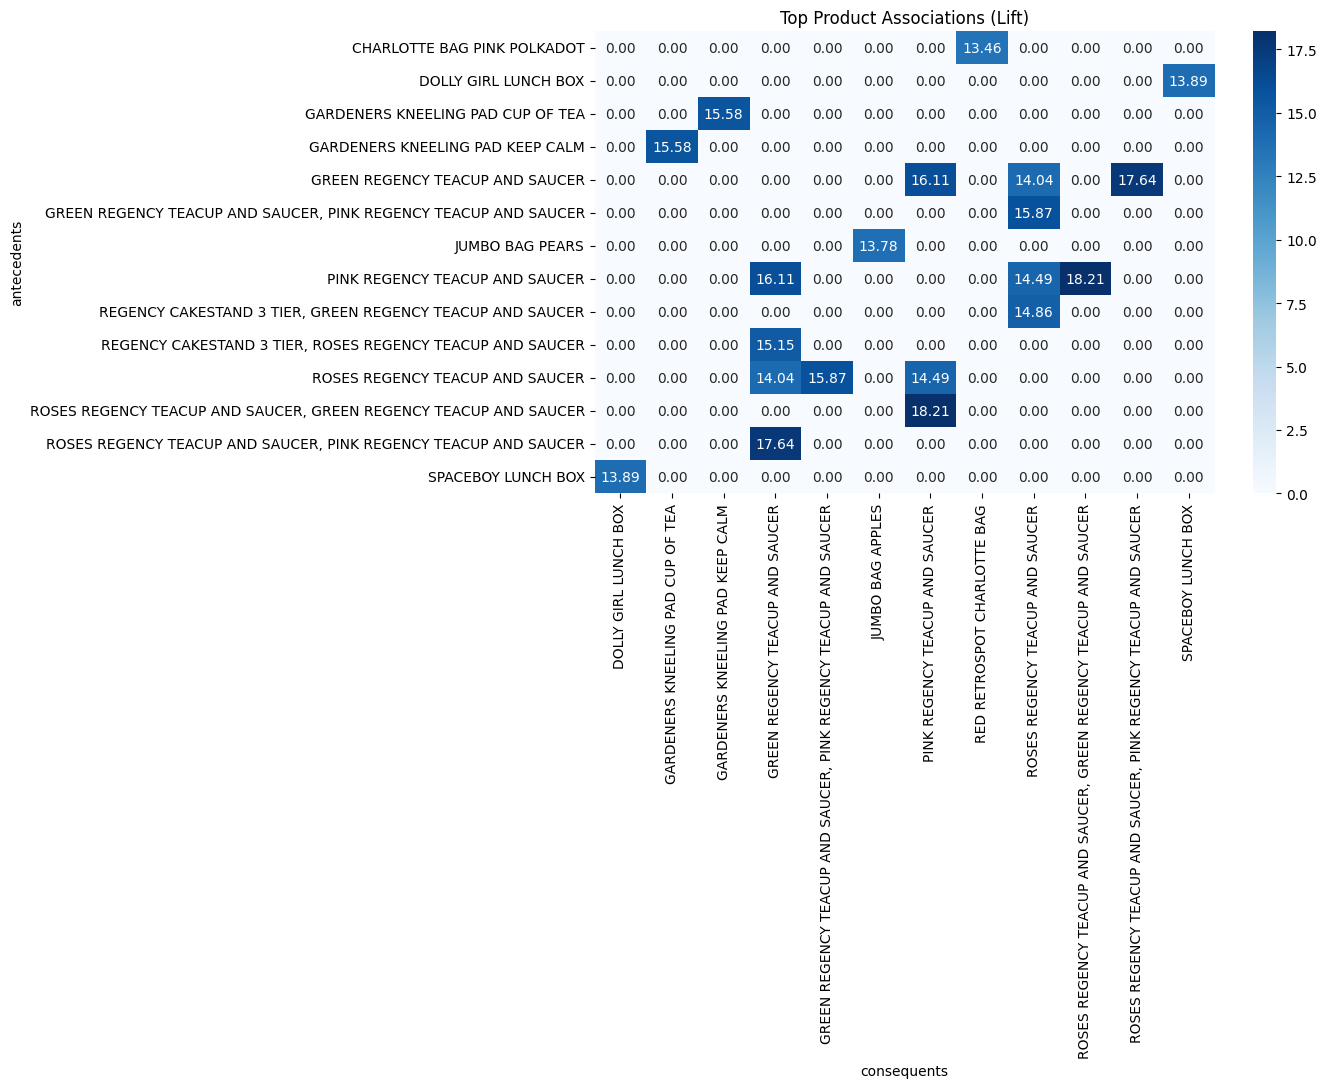

In [0]:
import seaborn as sns

top_rules = r50.sort_values('lift', ascending=False).head(20)

# Convert to strings
heat = top_rules.copy()
heat['antecedents'] = heat['antecedents'].apply(lambda x: ', '.join(list(x)))
heat['consequents'] = heat['consequents'].apply(lambda x: ', '.join(list(x)))

pivot = heat.pivot_table(
    index='antecedents',
    columns='consequents',
    values='lift',
    fill_value=0
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues")
plt.title("Top Product Associations (Lift)")
plt.show()


### Heatmap of Top Product Associations

**Key observations:**
- Several strong associations involve different variants of Regency teacups and saucers.
- These items frequently appear together in customer transactions, indicating complementary product relationships.

**Business Insight:**
- High-lift product pairs are ideal for bundle offers and cross-selling strategies.
- These combinations can also be used in recommendation systems to increase average basket size.


## Redundant / trivial rule filtering
We keep positive association rules (lift > 1) and drop subset-redundant rules with nearly identical confidence.



In [0]:
def remove_redundant_rules_simple(rules):
    # Keep only strong rules
    filtered = rules[rules['lift'] > 1].copy()

    # Remove rules where antecedent and consequent overlap
    filtered = filtered[
        filtered.apply(lambda r: len(r['antecedents'] & r['consequents']) == 0, axis=1)
    ]

    return filtered
r50_filtered = remove_redundant_rules_simple(r50)

print('Rules before filtering:', len(r50))
print('Rules after filtering:', len(r50_filtered))

# Convert to display-safe version
r50_filtered_display = r50_filtered.copy()
r50_filtered_display['antecedents'] = r50_filtered_display['antecedents'].apply(lambda x: ', '.join(list(x)))
r50_filtered_display['consequents'] = r50_filtered_display['consequents'].apply(lambda x: ', '.join(list(x)))

display(
    r50_filtered_display
    .sort_values('lift', ascending=False)
    .head(20)[['antecedents','consequents','support','confidence','lift']]
)


Rules before filtering: 63
Rules after filtering: 63


antecedents,consequents,support,confidence,lift
"ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER",PINK REGENCY TEACUP AND SAUCER,0.027395179258659103,0.7053455019556715,18.208056173360262
PINK REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER",0.027395179258659103,0.7071895424836601,18.20805617336026
"ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",GREEN REGENCY TEACUP AND SAUCER,0.027395179258659103,0.9046822742474916,17.6363924499896
GREEN REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",0.027395179258659103,0.5340572556762093,17.6363924499896
PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.03200324083451489,0.8261437908496733,16.105318441953948
GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.03200324083451489,0.6238894373149063,16.105318441953948
"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",ROSES REGENCY TEACUP AND SAUCER,0.027395179258659103,0.856012658227848,15.872805610031493
ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER",0.027395179258659103,0.5079812206572769,15.872805610031493
GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.027648369455134696,0.5980284775465499,15.580298647215391
GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.027648369455134696,0.7203166226912928,15.58029864721539


### Filtered Association Rules

After filtering, the number of rules remained the same, indicating that most generated rules were non-redundant.

**Item behavior insights:**
- Strong relationships exist between different variants of Regency teacups and saucers.
- For example, customers who purchase “ROSES REGENCY TEACUP AND SAUCER” are highly likely to also purchase “PINK” or “GREEN” variants.

**Business Insight:**
- Customers tend to purchase matching or related items from the same product line.
- These item pairs are ideal for bundle offers, cross-selling, and recommendation strategies.


# Task IV: Advanced Analysis & Business Applications

## 1) Segment analysis: UK vs Non-UK
We compare rule patterns for UK customers vs customers outside the UK.



In [0]:
# Identify all invoices that belong to UK customers
uk_invoices = set(df_clean.loc[df_clean['Country'].str.upper().eq('UNITED KINGDOM'), 'InvoiceNo'].unique())

# Create a basket matrix only for UK and non uk transactions
basket_binary_uk = basket_binary.loc[basket_binary.index.isin(uk_invoices)].copy()
basket_binary_nonuk = basket_binary.loc[~basket_binary.index.isin(uk_invoices)].copy()

# Print the number of invoices in each segment
print('UK invoices:', basket_binary_uk.shape[0])
print('Non-UK invoices:', basket_binary_nonuk.shape[0])



UK invoices: 17810
Non-UK invoices: 1938


### UK vs Non-UK Transaction Distribution

The dataset contains 17,810 UK invoices and 1,938 non-UK invoices. This shows that the majority of transactions come from UK customers, indicating that the business is primarily UK-focused.

Because of this large difference in transaction volume, stronger and more diverse association patterns are expected in the UK segment compared to the non-UK segment.


In [0]:
def mine_rules(basket_mat, min_support=0.02, min_conf=0.5):
    # Use boolean matrix + low_memory to avoid MemoryError on large sparse matrices
    basket_bool = basket_mat.astype(bool)
    fi_seg = apriori(basket_bool, min_support=min_support, use_colnames=True, low_memory=True)
    # If no frequent itemsets were found, return empty rules dataframe
    if fi_seg.empty:
        rules_seg = pd.DataFrame(columns=['antecedents','consequents','support','confidence','lift'])
        return fi_seg, rules_seg
    fi_seg['length'] = fi_seg['itemsets'].apply(len)
    rules_seg = association_rules(fi_seg, metric='confidence', min_threshold=min_conf)
    return fi_seg, rules_seg

SUP_SEG = 0.02
CONF_SEG = 0.5

fi_uk, rules_uk = mine_rules(basket_binary_uk, SUP_SEG, CONF_SEG)
fi_nonuk, rules_nonuk = mine_rules(basket_binary_nonuk, SUP_SEG, CONF_SEG)

print('UK frequent itemsets:', len(fi_uk), 'UK rules:', len(rules_uk))
print('Non-UK frequent itemsets:', len(fi_nonuk), 'Non-UK rules:', len(rules_nonuk))



UK frequent itemsets: 410 UK rules: 81
Non-UK frequent itemsets: 583 Non-UK rules: 326


### UK vs Non-UK Pattern Comparison

The UK segment produced 410 frequent itemsets and 81 association rules, while the non-UK segment produced 583 frequent itemsets and 326 rules.

Although the UK segment has far more transactions, the non-UK segment generated a higher number of itemsets and rules. This suggests that non-UK customers show more concentrated or consistent purchasing patterns, leading to stronger associations at the chosen thresholds.

In contrast, the UK segment reflects more diverse purchasing behavior across a wider product range.


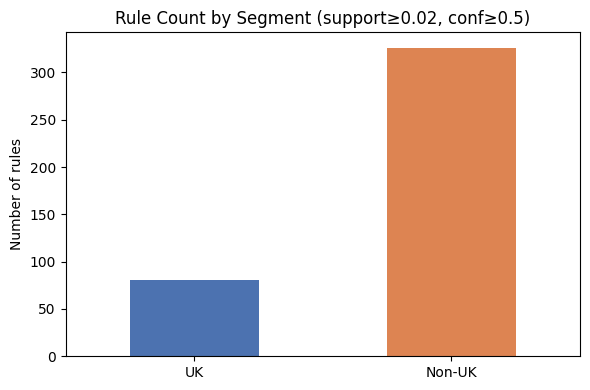

In [0]:
# VIS 16: Rule count by segment
plt.figure(figsize=(6,4))
seg_counts = pd.Series({'UK': len(rules_uk), 'Non-UK': len(rules_nonuk)})
seg_counts.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title(f'Rule Count by Segment (support≥{SUP_SEG}, conf≥{CONF_SEG})')
plt.ylabel('Number of rules')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



### Rule Count Comparison: UK vs Non-UK

The chart shows the number of association rules generated for each segment. The UK segment produced 81 rules, while the non-UK segment produced 326 rules at the same support and confidence thresholds.

Despite having fewer transactions, the non-UK segment generated significantly more rules. This suggests that non-UK customers exhibit more consistent or concentrated purchasing patterns, leading to stronger and more frequent product associations.

In contrast, the UK segment shows fewer rules, indicating more diverse purchasing behavior across a wider range of products.


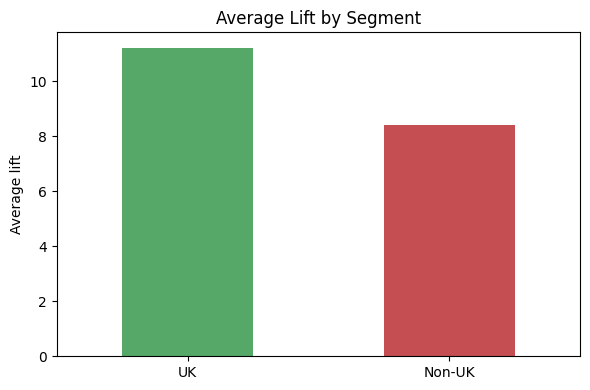

In [0]:
# VIS 17: Average lift by segment
plt.figure(figsize=(6,4))
seg_lift = pd.Series({'UK': rules_uk['lift'].mean() if len(rules_uk) else np.nan,
                      'Non-UK': rules_nonuk['lift'].mean() if len(rules_nonuk) else np.nan})
seg_lift.plot(kind='bar', color=['#55A868', '#C44E52'])
plt.title('Average Lift by Segment')
plt.ylabel('Average lift')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



### Average Lift Comparison: UK vs Non-UK

The average lift for the UK segment is higher than the non-UK segment. This indicates that, although the UK segment produced fewer rules, the relationships between products are generally stronger.

In contrast, the non-UK segment generated more rules, but with a lower average lift, suggesting that the associations are more frequent but slightly weaker.

This shows that UK customers tend to purchase strongly related product pairs, while non-UK customers display a larger number of moderate associations.


## Product bundle proposals
We convert high-quality rules into business-ready bundles.

Pricing suggestion heuristic:
- Lift 1.2–1.5 → 5% discount
- Lift 1.5–2.0 → 10% discount
- Lift > 2.0 → 15% discount

This is intentionally simple and should be validated against margins.



In [0]:
# list thresholds
def suggest_discount(lift):
    if lift > 2.0:
        return 15
    elif lift > 1.5:
        return 10
    elif lift > 1.2:
        return 5
    else:
        return 0

bundle_candidates = r50_filtered.sort_values(['lift','confidence','support'], ascending=False).head(30)

bundles = []
for _, row in bundle_candidates.iterrows():
    bundle_items = sorted(list(row['antecedents'] | row['consequents']))
    bundles.append({
        'Products in bundle': ' + '.join(bundle_items),
        'Support': row['support'],
        'Confidence': row['confidence'],
        'Lift': row['lift'],
        'Suggested discount %': suggest_discount(row['lift']),
        'Expected impact (short)': 'Higher AOV via cross-sell; improved recommendation relevance'
    })

bundles_df = pd.DataFrame(bundles).drop_duplicates(subset=['Products in bundle']).head(5)
bundles_df



,Products in bundle,Support,Confidence,Lift,Suggested discount %,Expected impact (short)
0,GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY...,0.027395,0.705346,18.208056,15,Higher AOV via cross-sell; improved recommenda...
4,GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY...,0.032003,0.826144,16.105318,15,Higher AOV via cross-sell; improved recommenda...
8,GARDENERS KNEELING PAD CUP OF TEA + GARDENERS ...,0.027648,0.598028,15.580299,15,Higher AOV via cross-sell; improved recommenda...
10,GREEN REGENCY TEACUP AND SAUCER + REGENCY CAKE...,0.020660,0.777143,15.150066,15,Higher AOV via cross-sell; improved recommenda...
12,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY...,0.030282,0.781699,14.494834,15,Higher AOV via cross-sell; improved recommenda...


### Based on the bundle results

**Observed patterns:**
- Many bundles involve Regency teacup variants.
- Lift values are very high, around 15–18.
- Confidence values are also high, around 0.59–0.82.

**Interpretation:**
- Customers who buy one item are very likely to buy the paired item.
- These products have strong complementary relationships.
- Such bundles are suitable for cross-selling and promotional offers.


## Final Business Interpretation and Recommendations

##### Key Findings
The analysis revealed that certain products, especially Regency teacup and saucer variants, are frequently purchased together. These item pairs show high support, confidence, and very high lift values (above 15), indicating strong complementary relationships and consistent customer buying patterns.

#####Marketing Recommendations
Targeted promotions and bundle discounts should be created for high-confidence product pairs. Email campaigns, website recommendations, and in-cart suggestions can be used to promote these bundles and increase average order value.

#####Regional Strategy
The UK segment produced fewer but stronger associations, while the non-UK segment generated more rules with slightly lower lift. This suggests that:
- UK customers prefer strongly related product combinations.
- Non-UK customers show more varied but frequent purchasing patterns.

#####Conclusion
The analysis shows clear product pairings that can be used to create smart bundles, improve inventory planning, and run targeted marketing campaigns to increase sales and average order value.

